Customer/ Product Lifetime Value (C/PLV) — also called LTV — is the total net value a business expects to earn from a customer/product over the entire relationship period.

CLV/PLV helps organizations:

Identify high-value customers

Decide how much to spend on customer acquisition

Improve retention strategies

Optimize marketing, pricing, and loyalty programs

Basic CLV/PLV Formula (Historical / Simple)
CLV
=
Average Purchase Value
×
Purchase Frequency
×
Customer Lifespan
CLV=Average Purchase Value×Purchase Frequency×Customer Lifespan

Where:

Average Purchase Value = Total Revenue / Total Purchases

Purchase Frequency = Total Purchases / Total Customers

Customer Lifespan = Average years/months a customer stays

**1 Define the Objective**

Objective:

To examine Product Lifetime Value (CLV) for each product

To identify high-value, medium-value, and low-value products

To support marketing strategy, retention planning, and budget allocation

Business Questions:

Who are the most profitable product ID ?

How long do product stay with the business?

How much revenue can be expected from a wide range of product over their lifetime?

2. Data Understanding & Collection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('/content/drive/MyDrive/LCV.csv')

# Preview data
df.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ProductID          5681 non-null   object 
 1   Weight             4705 non-null   float64
 2   FatContent         5681 non-null   object 
 3   ProductVisibility  5681 non-null   float64
 4   ProductType        5681 non-null   object 
 5   MRP                5681 non-null   float64
 6   OutletID           5681 non-null   object 
 7   EstablishmentYear  5681 non-null   int64  
 8   OutletSize         4075 non-null   object 
 9   LocationType       5681 non-null   object 
 10  OutletType         5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


,Weight,ProductVisibility,MRP,EstablishmentYear
count,4705.000000,5681.000000,5681.000000,5681.000000
mean,12.695633,0.065684,141.023273,1997.828903
std,4.664849,0.051252,61.809091,8.372256
min,4.555000,0.000000,31.990000,1985.000000
25%,8.645000,0.027047,94.412000,1987.000000
50%,12.500000,0.054154,141.415400,1999.000000
75%,16.700000,0.093463,186.026600,2004.000000
max,21.350000,0.323637,266.588400,2009.000000


In [ ]:
#missing values
df.isnull().sum()

,0
ProductID,0
Weight,976
FatContent,0
ProductVisibility,0
ProductType,0
MRP,0
OutletID,0
EstablishmentYear,0
OutletSize,1606
LocationType,0


3. Data Cleaning

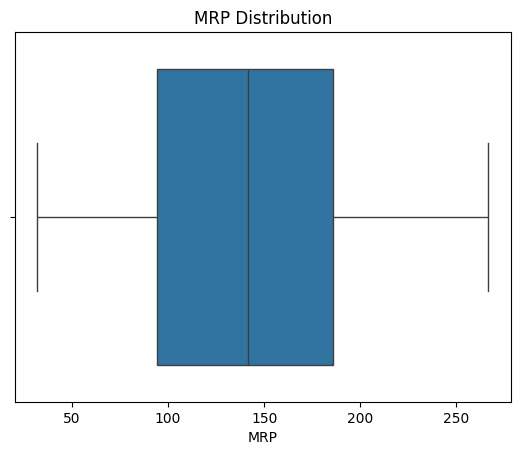

In [ ]:
#Visualizations
plt.figure()
sns.boxplot(x=df['MRP'])
plt.title('MRP Distribution')
plt.show()

In [ ]:
print(df.columns)

Index(['ProductID', 'Weight', 'FatContent', 'ProductVisibility', 'ProductType',
       'MRP', 'OutletID', 'EstablishmentYear', 'OutletSize', 'LocationType',
       'OutletType'],
      dtype='object')


In [ ]:
# Handle Missing Values

#Compute missing 'Weight' values with the mean
df['Weight'].fillna(df['Weight'].mean(), inplace=True)

# Compute missing 'OutletSize' values with the mode
# First, find the mode
mode_outlet_size = df['OutletSize'].mode()[0]
df['OutletSize'].fillna(mode_outlet_size, inplace=True)

print("Missing values after analysis:")
print(df.isnull().sum())

Missing values after imputation:
ProductID            0
Weight               0
FatContent           0
ProductVisibility    0
ProductType          0
MRP                  0
OutletID             0
EstablishmentYear    0
OutletSize           0
LocationType         0
OutletType           0
dtype: int64


/tmp/ipython-input-3475273185.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weight'].fillna(df['Weight'].mean(), inplace=True)
/tmp/ipython-input-3475273185.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [ ]:
# 2. Feature Engineering: Create 'OutletAge'

from datetime import datetime
current_year = datetime.now().year
df['OutletAge'] = current_year - df['EstablishmentYear']
print("DataFrame with new 'OutletAge' column:")
display(df[['EstablishmentYear', 'OutletAge']].head())

DataFrame with new 'OutletAge' column:


,EstablishmentYear,OutletAge
0,1999,27
1,2007,19
2,1998,28
3,2007,19
4,1985,41


These steps address the immediate data cleaning needs (missing values) and introduce a new potentially useful feature (`OutletAge`). Further steps like encoding categorical variables would depend on the specific type of analysis or modeling you intend to perform.

4. Identify Dependent & Independent Variables (Correlation)
Dependent Variable: MRP

Independent Variables:EstablishmentYear, ProductVisibility, Weight

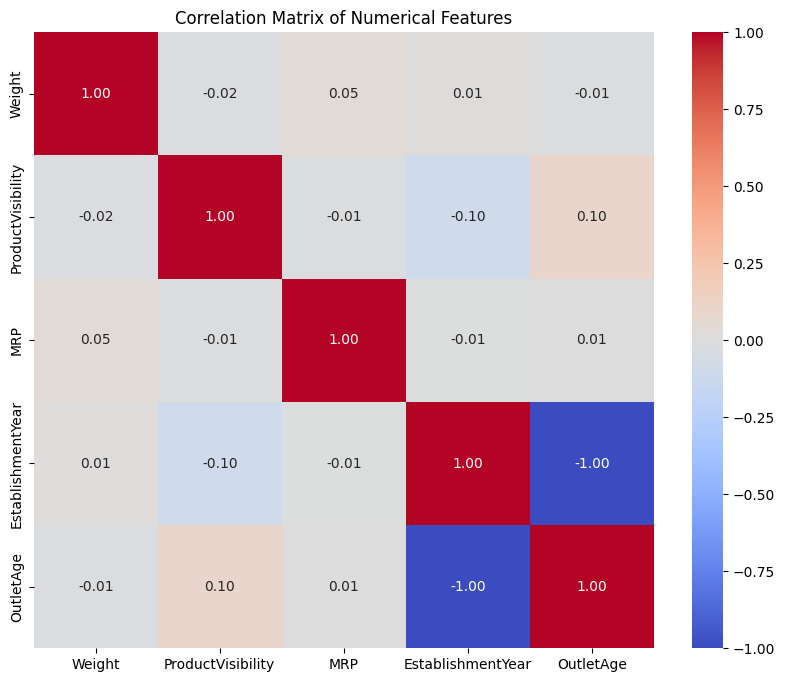

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the numerical columns for correlation analysis
numerical_df = df[['Weight', 'ProductVisibility', 'MRP', 'EstablishmentYear', 'OutletAge']]
# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()
# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

5. Develop Model, Analysis & Validation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Remove missing ProductID (if any)
df = df.dropna(subset=['ProductID'])
# Remove negative or zero values
df = df[(df['Weight'] > 0) & (df['MRP'] > 0)]

In [ ]:
df['Revenue'] = df['Weight'] * df['MRP']


In [ ]:
product_df = df.groupby('ProductID').agg({
    'EstablishmentYear': ['min', 'max'],
    'ProductVisibility': 'nunique',
    'Revenue': 'sum'
}).reset_index()

# Flatten the MultiIndex columns created by agg and then rename
product_df.columns = ['ProductID', 'Min_EstablishmentYear', 'Max_EstablishmentYear', 'Unique_ProductVisibility', 'Total_Revenue']
print(product_df.head())

  ProductID  Min_EstablishmentYear  Max_EstablishmentYear  \
0     DRA12                   1985                   1999   
1     DRA24                   1997                   2009   
2     DRA59                   2002                   2004   
3     DRB01                   1985                   2009   
4     DRB13                   1985                   2009   

   Unique_ProductVisibility  Total_Revenue  
0                         3    5071.181464  
1                         3    9511.693740  
2                         2    3046.542296  
3                         5    8039.507339  
4                         4    5897.624120  


In [ ]:
# Convert establishment years to datetime objects first for accurate lifespan calculation
product_df['Min_EstablishmentYear'] = pd.to_datetime(product_df['Min_EstablishmentYear'], format='%Y')
product_df['Max_EstablishmentYear'] = pd.to_datetime(product_df['Max_EstablishmentYear'], format='%Y')

product_df['Product_Lifespan_Days'] = (
    product_df['Max_EstablishmentYear'] - product_df['Min_EstablishmentYear']
).dt.days
product_df['Product_Lifespan_Years'] = (
    product_df['Product_Lifespan_Days'] / 365
)
# Replace zero lifespan with a minimum value to avoid division by zero later if needed
product_df['Product_Lifespan_Years'] = product_df['Product_Lifespan_Years'].replace(0, 0.1)
print(product_df.head())

  ProductID Min_EstablishmentYear Max_EstablishmentYear  \
0     DRA12            1985-01-01            1999-01-01   
1     DRA24            1997-01-01            2009-01-01   
2     DRA59            2002-01-01            2004-01-01   
3     DRB01            1985-01-01            2009-01-01   
4     DRB13            1985-01-01            2009-01-01   

   Unique_ProductVisibility  Total_Revenue  Product_Lifespan_Days  \
0                         3    5071.181464                   5113   
1                         3    9511.693740                   4383   
2                         2    3046.542296                    730   
3                         5    8039.507339                   8766   
4                         4    5897.624120                   8766   

   Product_Lifespan_Years  
0               14.008219  
1               12.008219  
2                2.000000  
3               24.016438  
4               24.016438  


In [ ]:
# Average Order Value (for products)
product_df['Avg_Order_Value'] = (
    product_df['Total_Revenue'] / customer_df['Unique_ProductVisibility']
)
# Product Lifetime Value (PLV) - adapted from CLV formula
product_df['PLV'] = (
    product_df['Avg_Order_Value'] *
    product_df['Unique_ProductVisibility']*
    product_df['Product_Lifespan_Years']
)
print(product_df[['ProductID', 'PLV']].head())

  ProductID            PLV
0     DRA12   71038.221445
1     DRA24  114218.503185
2     DRA59    6093.084592
3     DRB01  193080.332413
4     DRB13  141639.926133


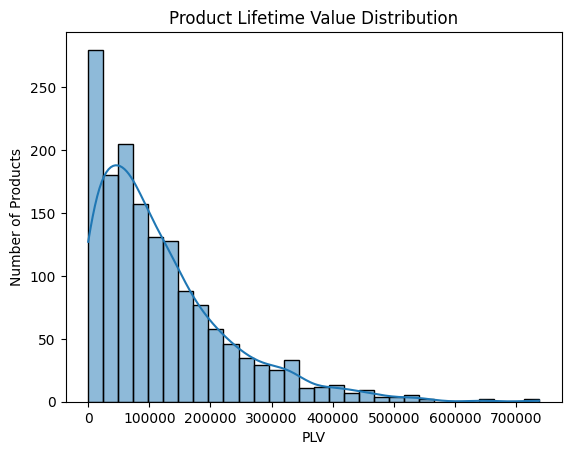

In [ ]:
plt.figure()
sns.histplot(product_df['PLV'], bins=30, kde=True)
plt.title('Product Lifetime Value Distribution')
plt.xlabel('PLV')
plt.ylabel('Number of Products')
plt.show()


6. Evaluation and Insights (Inferences & Datastory telling)

 1.The Product Lifetime Value (PLV) values indicate significant variation in long-term revenue contribution across products. This suggests that not all products contribute equally to business profitability over time.

2.Product DRB01    (PLV = 193080.332413)

Interpretation:

DRB01  has the highest PLV, indicating that it generates the maximum lifetime revenue compared to other products. This product likely experiences high repeat purchases, strong demand, or premium pricing.

Business Implication:

Treat as a star product

Ensure high availability and strong promotion

Use for cross-selling and bundling strategies



3. Product DRB13  (PLV = 141639.926133)
Interpretation:

DRB13 is also a high-performing product, contributing substantially to long-term revenue. Its PLV suggests stable customer demand and good retention.

Business Implication:

Maintain quality and supply consistency

Use as a core revenue driver

4. Product DRA24  (PLV = 114218.503185)

Interpretation:

DRA24 shows moderate lifetime value, indicating steady but not exceptional performance.

Business Implication:

Improve visibility through promotions

Upsell or bundle with high-PLV products

5. Product DRA12 (PLV = 71038.221445)

Interpretation:

DRA12 contributes moderately to revenue, suggesting average demand and repeat purchase behavior.

Business Implication:

Review pricing or promotional strategy

Evaluate customer feedback to boost repeat sales

6. Product DRA59 (PLV = 6093.084592)

Interpretation:

DRA59 has the lowest PLV, indicating limited long-term revenue contribution. This may be due to low demand, infrequent purchases, or price sensitivity.

Business Implication:

Consider cost optimization

Reposition, reprice, or discontinue if margins are low



7. Sugesstions & Data driven decisions

Allocate more marketing budget to high-PLV products

Bundle low-PLV products with high-PLV items

Use PLV insights for inventory planning and product portfolio optimization


8.  Conclusion

 Product Lifetime Value analysis helps businesses move beyond short-term sales and focus on long-term product profitability. By prioritizing high-PLV products and improving or rationalizing low-PLV products, firms can achieve sustainable revenue growth and better resource allocation.

Cohort analysis in retail segments customers into groups based on shared characteristics—commonly their first purchase date (acquisition cohort)—to track behavior, retention, and lifetime value over time. Instead of relying on aggregate data, it reveals how specific groups (e.g., Q1 vs. Q2 sign-ups) evolve, helping identify high-value segments, improve marketing ROI, and reduce churn by observing engagement patterns.

Key Components and Uses in Retail
Retention Rates: Tracks the percentage of customers from a specific cohort who return in subsequent periods, helping evaluate the long-term value of customers acquired during specific sales or campaigns.

Behavioral Analysis: Evaluates changes in purchasing habits, such as average order value (AOV) or purchase frequency, over a customer's lifecycle.
Product/Feature Adoption: Measures how quickly new customers adopt specific products or features after their initial interaction.

Marketing Effectiveness: Compares, for instance, the quality of customers acquired through a holiday sale versus a non-sale period, indicating whether to adjust acquisition strategies.

Common Cohort Types
Acquisition Cohorts: Groups users by the time they signed up or made their first purchase (e.g., January 2025 cohort).

Behavioral Cohorts: Groups users based on specific actions taken, such as purchasing a certain product category or engaging with a particular marketing channel.

Retail Benefits
By pinpointing exactly when customers disengage, retailers can create targeted retention campaigns, improve customer lifetime value (CLV), and make data-driven decisions on where to allocate marketing spend.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/LCV.csv')

# Convert EstablishmentYear to datetime, ensuring it's parsed as a year
df['EstablishmentYear'] = pd.to_datetime(df['EstablishmentYear'].astype(str), format='%Y')

df.head()

,ProductID,Weight,FatContent,ProductVisibility,ProductType,MRP,OutletID,EstablishmentYear,OutletSize,LocationType,OutletType
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999-01-01,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007-01-01,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998-01-01,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007-01-01,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985-01-01,Medium,Tier 3,Supermarket Type3


In [ ]:
# Remove missing ProductID
df = df.dropna(subset=['ProductID'])

# Remove negative or zero quantities (if available)
if 'Weight' in df.columns:
    df = df[df['Weight'] > 0]


Step 1: Identify First Purchase Month (Cohort Month)

In [ ]:
# Create establishment month period as a proxy for product cohort month
df['EstablishmentMonth'] = df['EstablishmentYear'].dt.to_period('M')

# Get the first establishment month for each product to define its cohort
df['ProductCohortMonth'] = (
    df.groupby('ProductID')['EstablishmentMonth']
      .transform('min')
)
print(df[['ProductID', 'EstablishmentYear', 'EstablishmentMonth', 'ProductCohortMonth']].head())

  ProductID             EstablishmentYear EstablishmentMonth  \
0     FDW58 1970-01-01 00:00:00.000001999            1970-01   
1     FDW14 1970-01-01 00:00:00.000002007            1970-01   
2     NCN55 1970-01-01 00:00:00.000001998            1970-01   
3     FDQ58 1970-01-01 00:00:00.000002007            1970-01   
4     FDY38 1970-01-01 00:00:00.000001985            1970-01   

  ProductCohortMonth  
0            1970-01  
1            1970-01  
2            1970-01  
3            1970-01  
4            1970-01  


Calculate Cohort Index (Product Age)

In [ ]:
def cohort_index(df):
    # Use 'EstablishmentMonth' and 'ProductCohortMonth' which were previously created
    year_diff = df['EstablishmentMonth'].dt.year - df['ProductCohortMonth'].dt.year
    month_diff = df['EstablishmentMonth'].dt.month - df['ProductCohortMonth'].dt.month
    return year_diff * 12 + month_diff + 1

df['ProductCohortIndex'] = cohort_index(df)

Build Cohort table

In [ ]:
# Count unique products per cohort and index
cohort_data = (
    df.groupby(['ProductCohortMonth', 'ProductCohortIndex'])['ProductID']
      .nunique()
      .reset_index()
)

# Pivot cohort table
cohort_table = cohort_data.pivot(
    index='ProductCohortMonth',
    columns='ProductCohortIndex',
    values='ProductID'
)

# Retention rate (adapted for products - e.g., how many unique products from a cohort are visible in subsequent periods)
cohort_size = cohort_table.iloc[:, 0]
retention_table = cohort_table.divide(cohort_size, axis=0)

retention_table

ProductCohortIndex,1
ProductCohortMonth,
1970-01,1.0


Cohort Retention Heat Map

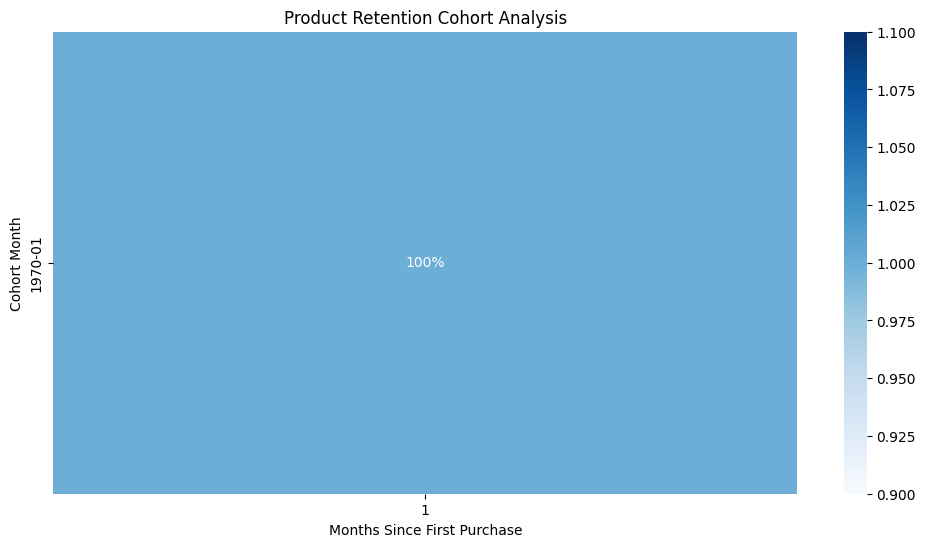

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(retention_table, annot=True, fmt='.0%', cmap='Blues')
plt.title('Product Retention Cohort Analysis')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.show()
